<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/LAB7_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LINK DATASET: https://drive.google.com/file/d/1IpRzU5_98KzY8AMm13AvfCuE6iWGXCBj/view?usp=sharing

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
import zipfile
import os

# 1. Definimos las rutas
ruta_zip = '/content/gdrive/MyDrive/SIS420IA/fruits-360-100x100-main.zip'
ruta_destino = '/content/dataset_frutas' # Carpeta temporal en Colab

# 2. Creamos la carpeta de destino si no existe
if not os.path.exists(ruta_destino):
    os.makedirs(ruta_destino)

# 3. Descomprimimos
print("Descomprimiendo... esto puede tardar un minuto porque el archivo es pesado.")
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_destino)
print("¡Listo! Archivo descomprimido en:", ruta_destino)

Descomprimiendo... esto puede tardar un minuto porque el archivo es pesado.
¡Listo! Archivo descomprimido en: /content/dataset_frutas


In [4]:
# Ver el contenido principal
contenido = os.listdir(ruta_destino)
print(f"Encontré {len(contenido)} carpetas/archivos en la raíz.")
print("Primeros 10 elementos:", contenido[:10])

# Contar cuántas imágenes hay en total (recorriendo subcarpetas)
total_imagenes = 0
for root, dirs, files in os.walk(ruta_destino):
    total_imagenes += len([f for f in files if f.endswith(('.jpg', '.jpeg', '.png'))])

print(f"\nTotal de imágenes encontradas: {total_imagenes}")

Encontré 1 carpetas/archivos en la raíz.
Primeros 10 elementos: ['fruits-360-100x100-main']

Total de imágenes encontradas: 180079


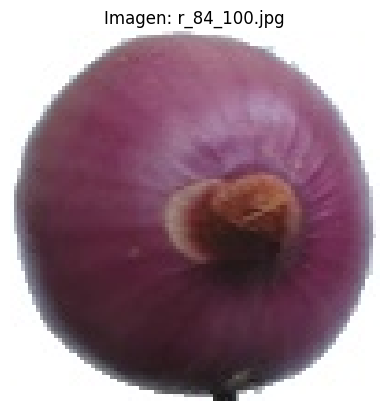

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Buscamos todas las rutas de imágenes
rutas_imagenes = []
for root, dirs, files in os.walk(ruta_destino):
    for file in files:
        if file.endswith('.jpg'):
            rutas_imagenes.append(os.path.join(root, file))

# Elegimos una al azar y la mostramos
if rutas_imagenes:
    img_random = random.choice(rutas_imagenes)
    img = mpimg.imread(img_random)
    plt.imshow(img)
    plt.title(f"Imagen: {os.path.basename(img_random)}")
    plt.axis('off')
    plt.show()
else:
    print("No se encontraron imágenes .jpg")

In [6]:
import os

ruta_destino = '/content/dataset_frutas' # La carpeta donde descomprimimos todo

print(f"🌳 Explorando el árbol de carpetas en: {ruta_destino}\n")

# Vemos qué hay en la carpeta principal
elementos_principales = os.listdir(ruta_destino)

for elemento in elementos_principales:
    ruta_elemento = os.path.join(ruta_destino, elemento)

    # Si es una carpeta (directorio), entramos a curiosear
    if os.path.isdir(ruta_elemento):
        print(f"📁 CARPETA PRINCIPAL: {elemento}/")

        # Leemos qué subcarpetas hay adentro (ej. las clases de frutas)
        subcarpetas = os.listdir(ruta_elemento)

        # Contamos cuántas subcarpetas hay
        carpetas_internas = [c for c in subcarpetas if os.path.isdir(os.path.join(ruta_elemento, c))]
        archivos_internos = [a for a in subcarpetas if os.path.isfile(os.path.join(ruta_elemento, a))]

        print(f"   ↳ Contiene {len(carpetas_internas)} subcarpetas (clases de frutas) y {len(archivos_internos)} archivos sueltos.")

        # Mostramos solo los primeros 5 nombres de las subcarpetas para no saturar la pantalla
        if len(carpetas_internas) > 0:
            print(f"   ↳ Ejemplos de subcarpetas aquí dentro: {carpetas_internas[:5]} ...")

        # Vamos un nivel más profundo solo para la primera subcarpeta, para ver cuántas fotos tiene
        if len(carpetas_internas) > 0:
            primera_subcarpeta = carpetas_internas[0]
            ruta_profunda = os.path.join(ruta_elemento, primera_subcarpeta)
            fotos = os.listdir(ruta_profunda)
            print(f"      ↳ Mirando dentro de la subcarpeta '{primera_subcarpeta}/': hay {len(fotos)} imágenes.")

        print("-" * 60)

🌳 Explorando el árbol de carpetas en: /content/dataset_frutas

📁 CARPETA PRINCIPAL: fruits-360-100x100-main/
   ↳ Contiene 2 subcarpetas (clases de frutas) y 2 archivos sueltos.
   ↳ Ejemplos de subcarpetas aquí dentro: ['Test', 'Training'] ...
      ↳ Mirando dentro de la subcarpeta 'Test/': hay 258 imágenes.
------------------------------------------------------------


In [7]:
import os

# Esta es la ruta donde le dijimos a Colab que guardara todo en el paso anterior
ruta_destino = '/content/dataset_frutas'

print("🔍 Iniciando el conteo de imágenes en todas las carpetas...")

total_imagenes = 0

# os.walk recorre la carpeta principal y TODAS sus subcarpetas
for root, dirs, files in os.walk(ruta_destino):
    for file in files:
        # Verificamos que el archivo termine en una extensión de imagen común
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            total_imagenes += 1

print("-" * 40)
print(f"✅ RESULTADO FINAL: Se han encontrado un total de {total_imagenes} imágenes.")
print("-" * 40)

🔍 Iniciando el conteo de imágenes en todas las carpetas...
----------------------------------------
✅ RESULTADO FINAL: Se han encontrado un total de 180079 imágenes.
----------------------------------------


In [8]:
import os

ruta_destino = '/content/dataset_frutas'

print(f"🌳 MAPA COMPLETO DE CARPETAS EN: {ruta_destino}\n")

# Usamos os.walk para recorrer todo
for root, dirs, files in os.walk(ruta_destino):

    # Calculamos el nivel de profundidad para hacer las "ramas" del árbol
    nivel = root.replace(ruta_destino, '').count(os.sep)
    indentacion = '    ' * nivel # 4 espacios por nivel

    # Sacamos el nombre de la carpeta en la que estamos parados
    nombre_carpeta = os.path.basename(root)
    if nivel == 0:
        nombre_carpeta = "📁 dataset_frutas (Carpeta Raíz)"
    else:
        nombre_carpeta = f"📁 {nombre_carpeta}/"

    # Contamos solo las imágenes dentro de ESTA carpeta específica
    num_imagenes = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    # Si hay imágenes, lo mostramos al lado
    info_archivos = f"  ---> [Contiene {num_imagenes} imágenes]" if num_imagenes > 0 else ""

    # Imprimimos la rama del árbol
    print(f"{indentacion}{nombre_carpeta}{info_archivos}")

🌳 MAPA COMPLETO DE CARPETAS EN: /content/dataset_frutas

📁 dataset_frutas (Carpeta Raíz)
    📁 fruits-360-100x100-main/
        📁 Test/
            📁 Tomato 11/  ---> [Contiene 158 imágenes]
            📁 Pear 10/  ---> [Contiene 231 imágenes]
            📁 Pear Monster 1/  ---> [Contiene 166 imágenes]
            📁 Plum 4/  ---> [Contiene 231 imágenes]
            📁 Cantaloupe 3/  ---> [Contiene 156 imágenes]
            📁 Pitahaya Red 1/  ---> [Contiene 166 imágenes]
            📁 Pomelo Sweetie 1/  ---> [Contiene 153 imágenes]
            📁 Zucchini 1/  ---> [Contiene 80 imágenes]
            📁 Pineapple 1/  ---> [Contiene 166 imágenes]
            📁 Raspberry 6/  ---> [Contiene 150 imágenes]
            📁 Raspberry 3/  ---> [Contiene 147 imágenes]
            📁 Blackberry 1/  ---> [Contiene 150 imágenes]
            📁 Avocado 1/  ---> [Contiene 143 imágenes]
            📁 Apple Red 3/  ---> [Contiene 144 imágenes]
            📁 Mandarine 1/  ---> [Contiene 166 imágenes]
           

In [9]:
import os
import numpy as np
from PIL import Image

# 1. Definimos la ruta donde extrajimos el dataset
ruta_training = '/content/dataset_frutas/fruits-360-100x100-main/Training'

# 2. Definimos las 15 "familias" objetivo (n = 15)
familias_objetivo = [
    'Apple', 'Banana', 'Cherry', 'Grape', 'Mango',
    'Orange', 'Peach', 'Pear', 'Pepper', 'Plum',
    'Potato', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon'
]

# Diccionario para convertir el texto (Manzana) a un número de etiqueta para la "hoja de respuestas"
label_to_id = {familia: i for i, familia in enumerate(familias_objetivo)}

X_list = []
y_list = []

print("⏳ Iniciando el preprocesamiento... Esto tomará unos un par de minutos, ten paciencia.")

# Límite de imágenes por familia (1000 x 15 = 15,000 imágenes) -> m > 10000
limite_por_familia = 1000
contadores = {familia: 0 for familia in familias_objetivo}

# 3. Recorremos todas las subcarpetas
for nombre_carpeta in os.listdir(ruta_training):
    ruta_carpeta = os.path.join(ruta_training, nombre_carpeta)

    if not os.path.isdir(ruta_carpeta): continue

    # Identificamos a qué familia pertenece esta subcarpeta (ej. 'Apple Red 1' -> 'Apple')
    familia_actual = None
    for familia in familias_objetivo:
        if nombre_carpeta.startswith(familia):
            familia_actual = familia
            break

    # Si no nos interesa esta fruta o ya juntamos las 1000, pasamos de largo
    if familia_actual is None or contadores[familia_actual] >= limite_por_familia:
        continue

    # 4. Procesamos las imágenes de la subcarpeta
    for archivo in os.listdir(ruta_carpeta):
        if contadores[familia_actual] >= limite_por_familia:
            break # Cupo lleno

        if archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            ruta_img = os.path.join(ruta_carpeta, archivo)

            # Abrimos la imagen (100x100 RGB)
            img = Image.open(ruta_img).convert('RGB')
            img_array = np.array(img)

            # --- EL SECRETO MATEMÁTICO (Para tu defensa) ---
            # APLANADO: Pasa de matriz 3D (100, 100, 3) a un vector 1D de 30000
            img_vector = img_array.flatten()

            # NORMALIZACIÓN: Dividimos entre 255.0 para dejar valores entre 0 y 1
            img_vector_norm = img_vector / 255.0

            X_list.append(img_vector_norm)
            y_list.append(label_to_id[familia_actual])

            contadores[familia_actual] += 1

# 5. Convertimos las listas a matrices de NumPy optimizadas para la RAM
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f"\n✅ ¡Procesamiento terminado!")
print(f"📊 Forma de X (La matriz de píxeles): {X.shape}")
print(f"📊 Forma de y (La hoja de respuestas secreta): {y.shape}")

print("\n📋 Resumen de tu nuevo Dataset:")
for familia, cantidad in contadores.items():
    print(f" - {familia}: {cantidad} imágenes")

# 6. Guardamos todo en un archivo comprimido .npz
ruta_npz = '/content/dataset_procesado.npz'
np.savez_compressed(ruta_npz, X=X, y=y)
print(f"\n📦 Dataset guardado exitosamente en: {ruta_npz}")

⏳ Iniciando el preprocesamiento... Esto tomará unos un par de minutos, ten paciencia.

✅ ¡Procesamiento terminado!
📊 Forma de X (La matriz de píxeles): (14475, 30000)
📊 Forma de y (La hoja de respuestas secreta): (14475,)

📋 Resumen de tu nuevo Dataset:
 - Apple: 1000 imágenes
 - Banana: 1000 imágenes
 - Cherry: 1000 imágenes
 - Grape: 1000 imágenes
 - Mango: 1000 imágenes
 - Orange: 1000 imágenes
 - Peach: 1000 imágenes
 - Pear: 1000 imágenes
 - Pepper: 1000 imágenes
 - Plum: 1000 imágenes
 - Potato: 1000 imágenes
 - Raspberry: 1000 imágenes
 - Strawberry: 1000 imágenes
 - Tomato: 1000 imágenes
 - Watermelon: 475 imágenes

📦 Dataset guardado exitosamente en: /content/dataset_procesado.npz


In [10]:
import shutil
# Mueve el archivo del temporal al Drive permanente
shutil.move('/content/dataset_procesado.npz', '/content/gdrive/MyDrive/SIS420IA/dataset_procesado.npz')
print("¡Archivo movido a tu Google Drive con éxito!")

¡Archivo movido a tu Google Drive con éxito!


**APRENDIZAJE NO SUPERVISADO**

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Forma de X lista para K-Means: (14475, 30000)


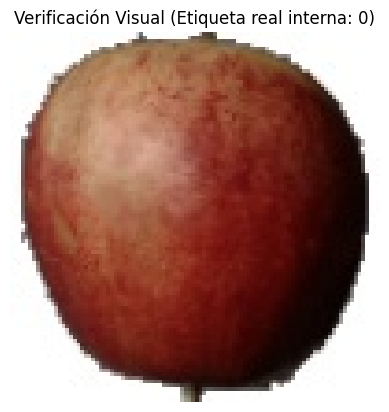

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/gdrive')

# 1. Carga del dataset que ya preprocesaste (aplanado y normalizado 0-1)
ruta_npz = '/content/gdrive/MyDrive/SIS420IA/dataset_procesado.npz'
data = np.load(ruta_npz)

X = data['X'] # Matriz de (14475, 30000)
y = data['y'] # Etiquetas reales (solo para comparar al final, ¡es aprendizaje NO supervisado!)

print(f"Forma de X lista para K-Means: {X.shape}")

# 2. Reconstrucción visual (reshape 100x100x3) en lugar de gráfico 3D
indice_azar = np.random.randint(0, len(X))
imagen_reconstruida = X[indice_azar].reshape(100, 100, 3)

plt.imshow(imagen_reconstruida)
plt.title(f"Verificación Visual (Etiqueta real interna: {y[indice_azar]})")
plt.axis('off')
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import MiniBatchKMeans, KMeans

# Vamos a elegir 3 píxeles al azar de los 30,000 para poder graficar sin que Colab explote
f1, f2, f3 = 15000, 16000, 17000

import plotly.express as px
import pandas as pd

def plot_clusters_3d_dinamico(X, y_pred):
    # Creamos un pequeño DataFrame solo para los 3 píxeles que vamos a graficar
    df_3d = pd.DataFrame({
        f"Pixel_{f1}": X[:, f1],
        f"Pixel_{f2}": X[:, f2],
        f"Pixel_{f3}": X[:, f3],
        "Grupo": y_pred.astype(str) # Convertimos a texto para que Plotly use colores distintos
    })

    # Creamos el gráfico interactivo
    fig = px.scatter_3d(df_3d, x=f"Pixel_{f1}", y=f"Pixel_{f2}", z=f"Pixel_{f3}",
                        color="Grupo", opacity=0.8, title="Clústeres 3D Interactivos")

    # Hacemos los puntos más pequeños para que se vea bien
    fig.update_traces(marker=dict(size=3))
    fig.show()

def plot_data_2d(X):
    plt.plot(X[:, f1], X[:, f2], 'k.', markersize=2)

def plot_centroids_2d(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, f1], centroids[:, f2],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, f1], centroids[:, f2],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

# Reemplaza SOLO estas dos funciones en tu primera celda

def plot_data_2d(X, y_pred=None):
    if y_pred is not None:
        # Si le pasamos los grupos, pinta los puntos de colores vivos
        plt.scatter(X[:, f1], X[:, f2], c=y_pred, s=2, cmap='tab20', alpha=0.9)
    else:
        # Por si acaso, el valor por defecto sigue siendo negro
        plt.plot(X[:, f1], X[:, f2], 'k.', markersize=2)

def plot_decision_boundaries_2d(clusterer, X, resolution=500, show_centroids=True, show_xlabels=True, show_ylabels=True):
    mins = X[:, [f1, f2]].min(axis=0) - 0.1
    maxs = X[:, [f1, f2]].max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))

    mesh_flat = np.c_[xx.ravel(), yy.ravel()]
    X_fake = np.zeros((len(mesh_flat), X.shape[1]), dtype=clusterer.cluster_centers_.dtype)
    X_fake[:, f1] = mesh_flat[:, 0]
    X_fake[:, f2] = mesh_flat[:, 1]

    Z = clusterer.predict(X_fake)
    Z = Z.reshape(xx.shape)

    # CAMBIO 1: Usamos 'tab20' para tener 15 colores distintos y 'alpha=0.4' para que el fondo sea un poco transparente
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="tab20", alpha=0.4)
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors='k', alpha=0.5)

    # CAMBIO 2: Predecimos los grupos reales y pintamos los puntos de esos mismos colores
    y_pred = clusterer.predict(X)
    plot_data_2d(X, y_pred)

    if show_centroids:
        plot_centroids_2d(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel(f"Píxel {f1}", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel(f"Píxel {f2}", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

CPU times: user 17.6 s, sys: 3.47 s, total: 21 s
Wall time: 17.8 s
\n✅ Modelo entrenado exitosamente.
Forma de los centroides descubiertos: (15, 30000)
\n--- Visualización 3D (3 Píxeles representativos) ---


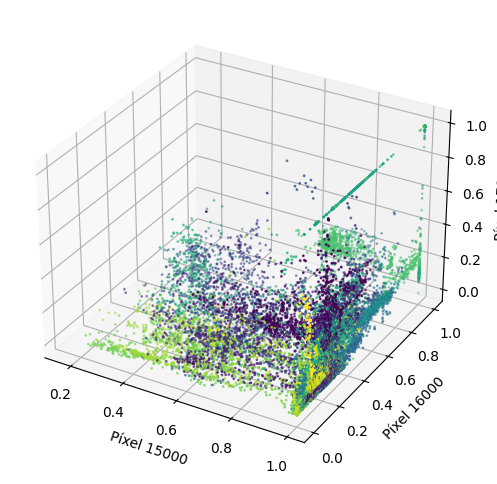

\n--- Fronteras de Decisión (2 Píxeles representativos) ---


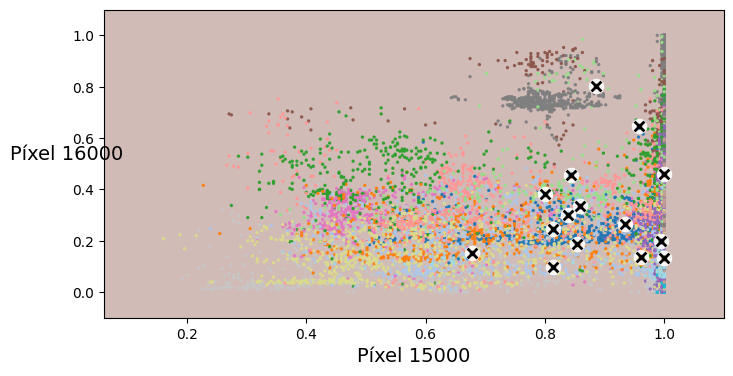

In [20]:
# Entrenamos con MiniBatchKMeans (Mucho más rápido que KMeans normal)
k = 15 # Son 15 familias de frutas
minibatch_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
%time minibatch_kmeans.fit(X)

y_pred = minibatch_kmeans.predict(X)

print("\\n✅ Modelo entrenado exitosamente.")
print("Forma de los centroides descubiertos:", minibatch_kmeans.cluster_centers_.shape)

# Graficamos en 3D
print("\\n--- Visualización 3D (3 Píxeles representativos) ---")
plot_clusters_3d(X, y_pred)

# Graficamos Fronteras en 2D
print("\\n--- Fronteras de Decisión (2 Píxeles representativos) ---")
plt.figure(figsize=(8, 4))
plot_decision_boundaries_2d(minibatch_kmeans, X)
plt.show()

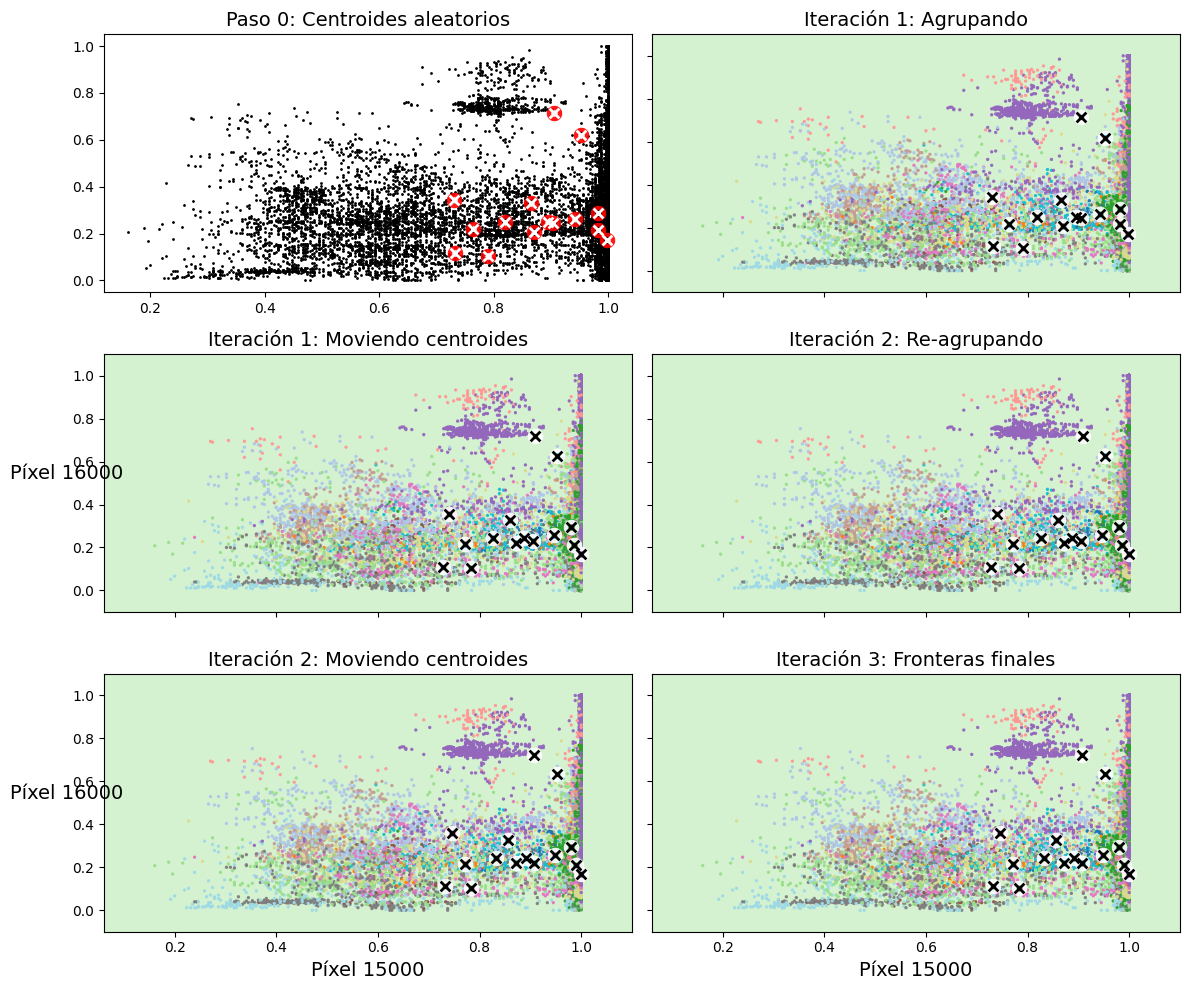

In [21]:
# Limitamos las iteraciones fuertemente para ver el paso a paso sin saturar la RAM
kmeans_iter1 = MiniBatchKMeans(n_clusters=k, init="random", n_init=1, max_iter=1, random_state=42)
kmeans_iter2 = MiniBatchKMeans(n_clusters=k, init="random", n_init=1, max_iter=2, random_state=42)
kmeans_iter3 = MiniBatchKMeans(n_clusters=k, init="random", n_init=1, max_iter=3, random_state=42)

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(12, 10))
plt.subplot(321)
plot_data_2d(X)
plot_centroids_2d(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.title("Paso 0: Centroides aleatorios", fontsize=14)

plt.subplot(322)
plot_decision_boundaries_2d(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Iteración 1: Agrupando", fontsize=14)

plt.subplot(323)
plot_decision_boundaries_2d(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids_2d(kmeans_iter2.cluster_centers_)
plt.title("Iteración 1: Moviendo centroides", fontsize=14)

plt.subplot(324)
plot_decision_boundaries_2d(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)
plt.title("Iteración 2: Re-agrupando", fontsize=14)

plt.subplot(325)
plot_decision_boundaries_2d(kmeans_iter2, X, show_centroids=False)
plot_centroids_2d(kmeans_iter3.cluster_centers_)
plt.title("Iteración 2: Moviendo centroides", fontsize=14)

plt.subplot(326)
plot_decision_boundaries_2d(kmeans_iter3, X, show_ylabels=False)
plt.title("Iteración 3: Fronteras finales", fontsize=14)

plt.tight_layout()
plt.show()

In [24]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import MiniBatchKMeans
import pandas as pd
import numpy as np

# 1. Elegimos 3 píxeles al azar (nuestros ejes X, Y, Z)
idx_x = 15000
idx_y = 16000
idx_z = 17000

# ¡TU EXCELENTE IDEA! Probamos con K menor, igual y mayor a nuestras familias reales
valores_k = [9, 15, 20, 30]

for k in valores_k:
    print(f"\n{'='*50}")
    print(f"ENTRENANDO MINIBATCH K-MEANS CON K = {k}")
    print(f"{'='*50}")

    # 2. Instanciar y entrenar con TODAS las 30,000 columnas (píxeles)
    minibatch_kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=1024,
        random_state=42,
        n_init=1 # Optimizado para que Colab no se sature
    )

    etiquetas = minibatch_kmeans.fit_predict(X)

    # 3. EXTRAER LOS CENTROIDES: Sacamos la posición central de los grupos
    centroides = minibatch_kmeans.cluster_centers_
    centroides_x = centroides[:, idx_x]
    centroides_y = centroides[:, idx_y]
    centroides_z = centroides[:, idx_z]

    # --- PREPARAR DATOS PARA GRAFICAR ---
    # Tomamos una muestra aleatoria de 5000 imágenes para que el navegador no explote al girar el 3D
    n_muestras = min(5000, X.shape[0])
    indices_muestra = np.random.choice(X.shape[0], n_muestras, replace=False)

    # Creamos el DataFrame temporal solo con los 3 píxeles que Plotly necesita
    df_plot = pd.DataFrame({
        'Pixel_X': X[indices_muestra, idx_x],
        'Pixel_Y': X[indices_muestra, idx_y],
        'Pixel_Z': X[indices_muestra, idx_z],
        'Cluster': etiquetas[indices_muestra].astype(str) # En texto para colores distintos
    })

    # 4. Graficar los puntos de las frutas en 3D
    fig = px.scatter_3d(
        df_plot,
        x='Pixel_X',
        y='Pixel_Y',
        z='Pixel_Z',
        color='Cluster',
        title=f'Dispersión 3D de Frutas con K={k} y Posición de CENTROIDES',
        opacity=0.4, # Transparente para que los centroides resalten
        width=900,
        height=700
    )

    # 5. AÑADIR LOS CENTROIDES (Diamantes negros) A LA GRÁFICA
    fig.add_trace(go.Scatter3d(
        x=centroides_x,
        y=centroides_y,
        z=centroides_z,
        mode='markers',
        marker=dict(size=12, color='black', symbol='diamond', line=dict(width=2, color='white')),
        name='Centroides'
    ))

    fig.show()


ENTRENANDO MINIBATCH K-MEANS CON K = 9



ENTRENANDO MINIBATCH K-MEANS CON K = 15



ENTRENANDO MINIBATCH K-MEANS CON K = 20



ENTRENANDO MINIBATCH K-MEANS CON K = 30


In [28]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import numpy as np

kmeans_per_k = []
inertias = []
silhouette_scores = []

# Los valores de K que queremos probar
valores_k_eval = [50, 40, 30, 20, 15, 10]

print(f"Iniciando evaluación sobre el dataset completo de {X.shape[0]} muestras...")

# 1. PASO CLAVE: Mezclamos TODO el dataset para que la muestra sea justa
np.random.seed(42)
indices_azar = np.random.choice(X.shape[0], 5000, replace=False) # Subimos a 5000
X_eval = X[indices_azar]

for k in valores_k_eval:
    # ENTRENAMIENTO: Usamos las 14,475 imágenes (CUMPLIMOS AL ING)
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024, n_init=1)
    kmeans.fit(X)

    kmeans_per_k.append(kmeans)
    inertias.append(kmeans.inertia_)

    # EVALUACIÓN: Usamos la muestra de 5000 para que la RAM no explote
    etiquetas_eval = kmeans.predict(X_eval)
    score = silhouette_score(X_eval, etiquetas_eval)
    silhouette_scores.append(score)

    print(f"✔ K={k} evaluado -> Inercia: {kmeans.inertia_:e} | Silueta: {score:.4f}")

print("\n--- EVALUACIÓN FINALIZADA ---")

Iniciando evaluación sobre el dataset completo de 14475 muestras...
✔ K=50 evaluado -> Inercia: 8.368586e+06 | Silueta: 0.1716
✔ K=40 evaluado -> Inercia: 9.060106e+06 | Silueta: 0.1668
✔ K=30 evaluado -> Inercia: 1.012935e+07 | Silueta: 0.1523
✔ K=20 evaluado -> Inercia: 1.158724e+07 | Silueta: 0.1445
✔ K=15 evaluado -> Inercia: 1.267759e+07 | Silueta: 0.1282
✔ K=10 evaluado -> Inercia: 1.396420e+07 | Silueta: 0.1370

--- EVALUACIÓN FINALIZADA ---


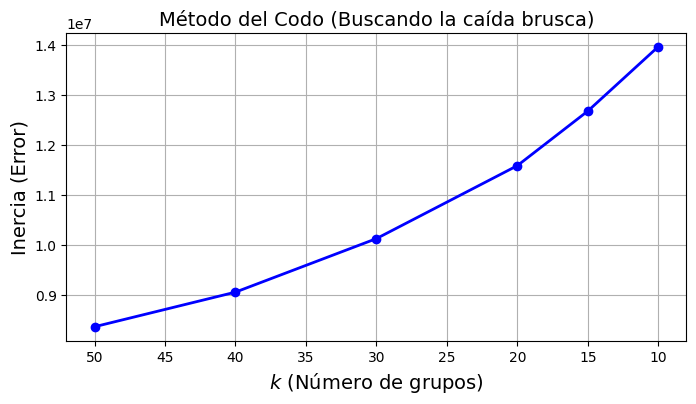

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(valores_k_eval, inertias, "bo-", linewidth=2)
plt.xlabel("$k$ (Número de grupos)", fontsize=14)
plt.ylabel("Inercia (Error)", fontsize=14)
# Invertimos el eje X para que vaya "bajando desde 50" visualmente como querías
plt.gca().invert_xaxis()
plt.title("Método del Codo (Buscando la caída brusca)", fontsize=14)
plt.grid(True)
plt.show()

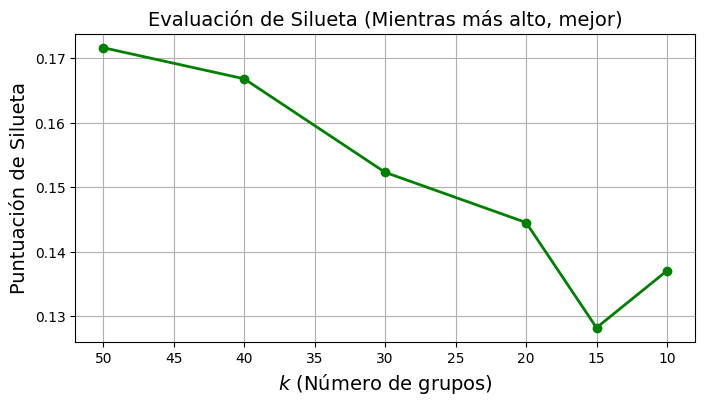

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(valores_k_eval, silhouette_scores, "go-", linewidth=2)
plt.xlabel("$k$ (Número de grupos)", fontsize=14)
plt.ylabel("Puntuación de Silueta", fontsize=14)
plt.gca().invert_xaxis()
plt.title("Evaluación de Silueta (Mientras más alto, mejor)", fontsize=14)
plt.grid(True)
plt.show()

**APRENDISAJE SEMI-SUPERVISADO**

In [31]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. División del dataset (Siguiendo la técnica del Ing./Aux.)
# Usamos el 80% para entrenar y el 20% para testear al final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ División completada:")
print(f"Muestras para entrenamiento (X_train): {X_train.shape}")
print(f"Muestras para evaluación final (X_test): {X_test.shape}")

✅ División completada:
Muestras para entrenamiento (X_train): (11580, 30000)
Muestras para evaluación final (X_test): (2895, 30000)


In [32]:
from sklearn.cluster import MiniBatchKMeans

# 2. Configuramos K=50 como lo hace el auxiliar con el dataset de dígitos/sangre
k = 50
minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=1024, random_state=42, n_init=1)

# TRUCO DEL AUXILIAR: fit_transform
# No solo entrena, sino que nos devuelve la distancia de CADA fruta a los 50 centroides.
# X_digits_dist tendrá una forma de (muestras_train, 50)
X_digits_dist = minibatch_kmeans.fit_transform(X_train)

print(f"✅ K-Means (K=50) finalizado sobre X_train.")
print(f"Forma de la matriz de distancias: {X_digits_dist.shape}")

# Mostramos los valores de la primera fruta para ver que son distancias matemáticas
print("\nDistancias de la primera fruta hacia cada uno de los 50 centroides:")
print(X_digits_dist[0])

✅ K-Means (K=50) finalizado sobre X_train.
Forma de la matriz de distancias: (11580, 50)

Distancias de la primera fruta hacia cada uno de los 50 centroides:
[ 75.492966  96.27183   67.1997    89.91343   68.89353   89.91644
 101.81604   77.98519   69.21977   88.04192  102.260284  83.88028
  90.996155  89.2323    24.40764   90.52933   73.46212   60.07826
  71.61738   92.476265  86.7175    77.987564  74.768974  75.86785
  70.47855   98.47818   83.38329   84.84141   87.31595   72.816986
  87.60266   56.260757  74.29608   65.77979   64.33066   74.637
  80.57529   81.000946  97.64101   71.482445  88.61006   95.145645
  42.083008  89.47893   80.80348   76.96636   83.4552    71.42518
  88.61738   83.86745 ]
